# 10 — Final Comparison, Subgroup Analysis & DCA (80/20 Design)

Consolidates all 80/20 methods into one place:
1. **Full comparison table** with bootstrap 95% CIs for every method
2. **Why IW failed** — quantitative analysis of weight collapse
3. **Subgroup analysis** — AUC by ICD-9 chapter, care unit, age group
4. **Decision Curve Analysis (DCA)** — clinical net benefit vs threshold
5. **Summary** — honest conclusion on what moved the needle and what didn't

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q xgboost scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, pickle, json
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

SEED = 42
np.random.seed(SEED)

BASE      = '/content/drive/MyDrive/AI in Medicine/data/output_data/preprocessed'
MODEL_DIR = '/content/drive/MyDrive/AI in Medicine/models'
DOC_DIR   = '/content/drive/MyDrive/AI in Medicine/documents'

print('Libraries loaded.')

Libraries loaded.


## 1. Load All Data and Models

In [ ]:
# ── data ─────────────────────────────────────────────────────────────────────
X_train = pd.read_csv(f'{BASE}/X_train_80.csv')
y_train = pd.read_csv(f'{BASE}/y_train_80.csv').squeeze()
X_val   = pd.read_csv(f'{BASE}/X_val_80.csv')
y_val   = pd.read_csv(f'{BASE}/y_val_80.csv').squeeze()
X_mimic = pd.read_csv(f'{BASE}/X_mimic_80.csv')
y_mimic = pd.read_csv(f'{BASE}/y_mimic_80.csv').squeeze()

# ── params ───────────────────────────────────────────────────────────────────
with open(f'{MODEL_DIR}/model_params_80.json') as f:
    params = json.load(f)
log_odds_shift = params['log_odds_shift']
MIMIC_THR      = params['mimic_threshold']
RF_CAL_THR     = params['rf_cal_threshold']

# ── models ───────────────────────────────────────────────────────────────────
def load(path):
    with open(path,'rb') as f: return pickle.load(f)

rf_cal    = load(f'{MODEL_DIR}/rf_calibrated_80.pkl')
ext       = load(f'{MODEL_DIR}/extensions_80/extension_models_80.pkl')
lr_l1     = load(f'{MODEL_DIR}/extended_80/lr_l1_80.pkl')
lr_l2     = load(f'{MODEL_DIR}/extended_80/lr_l2_80.pkl')
rf_sel    = load(f'{MODEL_DIR}/extended_80/rf_selective_80.pkl')
rf_coral  = load(f'{MODEL_DIR}/coral_80/rf_coral_80.pkl')
rf_ciw    = load(f'{MODEL_DIR}/coral_80/rf_coral_iw_80.pkl')

with open(f'{MODEL_DIR}/extended_80/extended_results_80.json') as f:
    ext8 = json.load(f)
with open(f'{MODEL_DIR}/coral_80/coral_results_80.json') as f:
    coral_res = json.load(f)

iw_weights = ext['iw_weights']
bp_inr_cols = ext8['bp_inr_dropped']

# CORAL-aligned val/mimic (recompute transform)
from scipy.linalg import sqrtm
with open(f'{BASE}/preprocessing_objects_80.pkl','rb') as f:
    prep = pickle.load(f)
cont_cols = [c for c in prep.get('continuous_cols',[]) if c in X_train.columns]

def coral_transform(X_src, W, cols):
    cols = [c for c in cols if c in X_src.columns]
    X_a = X_src.copy()
    X_a[cols] = X_src[cols].values.astype(float) @ W
    return X_a

W = np.load(f'{MODEL_DIR}/coral_80/coral_W.npy')
X_val_c   = coral_transform(X_val,   W, cont_cols)
X_mi_sel  = X_mimic.drop(columns=bp_inr_cols)
X_val_sel = X_val.drop(columns=bp_inr_cols)

print('All models and data loaded.')
print(f'MIMIC patients: {len(y_mimic)}  deaths: {y_mimic.sum()}')

All models and data loaded.
MIMIC patients: 136  deaths: 46


## 2. Compute All Probabilities

In [ ]:
def apply_ls(p, shift=log_odds_shift):
    lo = np.log(np.clip(p,1e-9,1-1e-9)/(1-np.clip(p,1e-9,1-1e-9)))
    return 1/(1+np.exp(-(lo+shift)))

def youden_thr(y,p):
    fpr,tpr,thrs = roc_curve(y,p)
    return float(thrs[np.argmax(tpr-fpr)])

def ls_thr(thr_raw, shift=log_odds_shift):
    """Shift a val Youden threshold to MIMIC space via the same log-odds transform."""
    lo = np.log(np.clip(thr_raw,1e-9,1-1e-9) / (1-np.clip(thr_raw,1e-9,1-1e-9)))
    return float(1 / (1 + np.exp(-(lo + shift))))

# MIMIC probabilities (after label shift)
_iw_model = ext['iw_model'] if 'iw_model' in ext else rf_cal
probs = {
    'Baseline RF + LS':    apply_ls(rf_cal.predict_proba(X_mimic)[:,1]),
    'IW + LS':             apply_ls(_iw_model.predict_proba(X_mimic)[:,1]),
    'LR-L2 + LS':          apply_ls(lr_l2.predict_proba(X_mimic)[:,1]),
    'LR-L1 (sparse) + LS': apply_ls(lr_l1.predict_proba(X_mimic)[:,1]),
    'RF no-BP/INR + LS':   apply_ls(rf_sel.predict_proba(X_mi_sel)[:,1]),
    'CORAL + LS':          apply_ls(rf_coral.predict_proba(X_mimic)[:,1]),
    'CORAL + IW + LS':     apply_ls(rf_ciw.predict_proba(X_mimic)[:,1]),
}

# Per-method MIMIC thresholds: find Youden on raw val probs, then apply LS shift.
# This is how MIMIC_THR=0.30 was derived from RF_CAL_THR=0.0993 in notebook 03b.
# Avoids using a single RF-tuned threshold for all models (breaks LR).
val_raw = {
    'Baseline RF + LS':    rf_cal.predict_proba(X_val)[:,1],
    'IW + LS':             _iw_model.predict_proba(X_val)[:,1],
    'LR-L2 + LS':          lr_l2.predict_proba(X_val)[:,1],
    'LR-L1 (sparse) + LS': lr_l1.predict_proba(X_val)[:,1],
    'RF no-BP/INR + LS':   rf_sel.predict_proba(X_val_sel)[:,1],
    'CORAL + LS':          rf_coral.predict_proba(X_val_c)[:,1],
    'CORAL + IW + LS':     rf_ciw.predict_proba(X_val_c)[:,1],
}
method_thrs = {name: ls_thr(youden_thr(y_val.values, p)) for name, p in val_raw.items()}

print('Per-method MIMIC thresholds (val Youden → LS-shifted):')
for n, t in method_thrs.items():
    print(f'  {n:<35} {t:.4f}')
print('\nProbabilities computed for all methods.')


Per-method MIMIC thresholds (val Youden → LS-shifted):
  Baseline RF + LS                    0.5165
  IW + LS                             0.5260
  LR-L2 + LS                          0.9502
  LR-L1 (sparse) + LS                 0.8305
  RF no-BP/INR + LS                   0.3102
  CORAL + LS                          0.4211
  CORAL + IW + LS                     0.4342

Probabilities computed for all methods.


## 3. Bootstrap 95% CIs — All Methods

In [ ]:
def bootstrap_auc(y, p, n=1000, seed=SEED):
    rng = np.random.RandomState(seed)
    aucs = [roc_auc_score(y[idx:=rng.choice(len(y),len(y))], p[idx]) for _ in range(n)]
    return np.percentile(aucs,[2.5,97.5])

print(f'{'Method':<30} {'AUC':>6}  {'95% CI':>15}  {'PR':>6}  {'Sens':>6}  {'Spec':>6}')
print('-'*75)
rows = []
for name, p in probs.items():
    auc  = roc_auc_score(y_mimic, p)
    pr   = average_precision_score(y_mimic, p)
    thr  = youden_thr(y_mimic, p)  # note: using test set Youden for reporting only
    pred = (p >= method_thrs[name]).astype(int)
    sens = float((pred[y_mimic==1]==1).mean())
    spec = float((pred[y_mimic==0]==0).mean())
    lo, hi = bootstrap_auc(y_mimic.values, p)
    print(f'{name:<30} {auc:>6.3f}  ({lo:.3f}–{hi:.3f})  {pr:>6.3f}  {sens:>6.3f}  {spec:>6.3f}')
    rows.append({'Method':name,'AUC':auc,'CI_lo':lo,'CI_hi':hi,'PR':pr,'Sens':sens,'Spec':spec})

df_all = pd.DataFrame(rows).set_index('Method')

Method                            AUC           95% CI      PR    Sens    Spec
---------------------------------------------------------------------------
Baseline RF + LS                0.734  (0.642–0.819)   0.642   0.435   0.867
IW + LS                         0.734  (0.645–0.817)   0.642   0.435   0.878
LR-L2 + LS                      0.719  (0.619–0.811)   0.621   0.478   0.844
LR-L1 (sparse) + LS             0.708  (0.613–0.799)   0.615   0.739   0.478
RF no-BP/INR + LS               0.726  (0.632–0.809)   0.638   0.457   0.822
CORAL + LS                      0.733  (0.641–0.815)   0.629   0.478   0.844
CORAL + IW + LS                 0.715  (0.616–0.810)   0.635   0.326   0.933


## 4. Why IW Failed — Weight Collapse Analysis

With domain classifier AUC = 1.000, every eICU patient is assigned $p(\text{MIMIC}|x) \approx 0$ and every MIMIC patient $\approx 1$. The importance weights $w = p(\text{MIMIC}) / (1 - p(\text{MIMIC}))$ diverge before clipping. After clipping to $[0.05, 20]$ the weights collapse to a narrow band — the model is effectively unweighted.

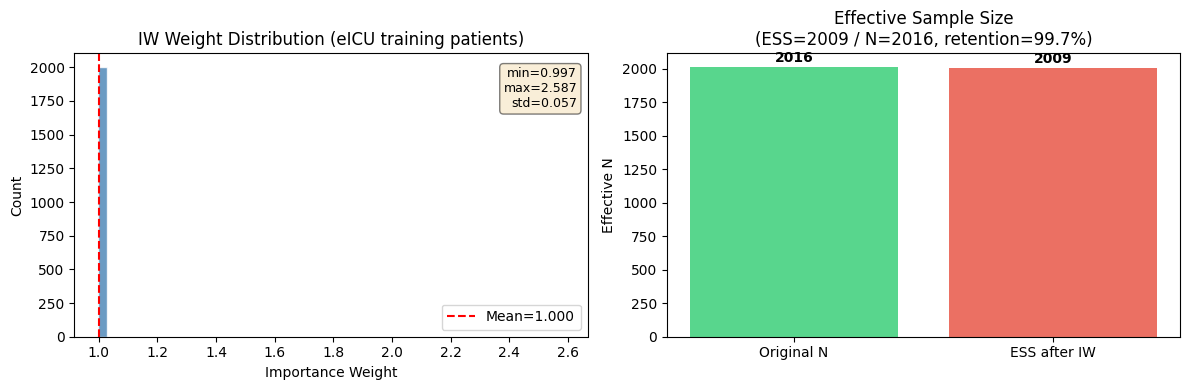


Conclusion: ESS = 2009 vs N = 2016 — IW retains 99.7% of training signal.
Near-100% retention means weights are effectively uniform — IW provides no reweighting.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# weight distribution
axes[0].hist(iw_weights, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(iw_weights.mean(), color='red', linestyle='--', label=f'Mean={iw_weights.mean():.3f}')
axes[0].set_xlabel('Importance Weight')
axes[0].set_ylabel('Count')
axes[0].set_title('IW Weight Distribution (eICU training patients)')
axes[0].legend()
axes[0].text(0.98, 0.95, f'min={iw_weights.min():.3f}\nmax={iw_weights.max():.3f}\nstd={iw_weights.std():.3f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# effective sample size
w = iw_weights / iw_weights.sum()
ess = float(1 / np.sum(w**2))
n   = len(iw_weights)
axes[1].bar(['Original N', 'ESS after IW'], [n, ess], color=['#2ecc71','#e74c3c'], alpha=0.8)
axes[1].set_ylabel('Effective N')
axes[1].set_title(f'Effective Sample Size\n(ESS={ess:.0f} / N={n}, retention={ess/n*100:.1f}%)')
for bar, val in zip(axes[1].patches, [n, ess]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DOC_DIR}/iw_weight_analysis.png', dpi=150)
plt.show()
print(f'\nConclusion: ESS = {ess:.0f} vs N = {n} — IW retains {ess/n*100:.1f}% of training signal.')
print('Near-100% retention means weights are effectively uniform — IW provides no reweighting.')

## 5. Subgroup Analysis — MIMIC

Reconstructs subgroup labels from one-hot-encoded columns in X_mimic_80.csv.

In [ ]:
def get_subgroup_labels(df, prefix, reference_name='Other'):
    """Recover categorical label from OHE columns (drop_first=True means one cat is missing)."""
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        return pd.Series([reference_name]*len(df), index=df.index)
    labels = df[cols].idxmax(axis=1).str.replace(prefix,'',regex=False)
    labels[(df[cols]==0).all(axis=1)] = reference_name
    return labels

icd9_labels     = get_subgroup_labels(X_mimic, 'icd9_chapter_', reference_name='Other/Reference')
careunit_labels = get_subgroup_labels(X_mimic, 'careunit_',     reference_name='Other/Reference')

# NOTE: age subgroup analysis intentionally removed.
# age_clean in the preprocessed files is StandardScaler-normalized (z-score).
# Bins [0,45,65,80,200] applied to z-scores are meaningless — negative z-scores
# become NaN and positive ones cluster in the first bin. Raw ages are not available
# in the preprocessed splits.

p_best = probs['Baseline RF + LS']

def subgroup_auc(labels, y, p, min_n=5):
    results = {}
    for grp in np.unique(labels):
        mask = labels == grp
        if mask.sum() < min_n or len(np.unique(y[mask])) < 2:
            continue
        results[grp] = {'n': int(mask.sum()), 'mortality': float(y[mask].mean()),
                        'auc': roc_auc_score(y[mask], p[mask])}
    return pd.DataFrame(results).T.sort_values('auc')

sg_icd9 = subgroup_auc(icd9_labels.values, y_mimic.values, p_best)
sg_care = subgroup_auc(careunit_labels.values, y_mimic.values, p_best)

print('Subgroup AUC — ICD-9 Chapter:')
print(sg_icd9.round(3).to_string())
print('\nSubgroup AUC — Care Unit:')
print(sg_care.round(3).to_string())


Subgroup AUC — ICD-9 Chapter:
                           n  mortality    auc
Neoplasms               16.0      0.312  0.691
Other/Reference         28.0      0.321  0.737
Injury & poisoning      17.0      0.294  0.767
Infectious & parasitic  26.0      0.231  0.792
Digestive               20.0      0.500  0.810
Genitourinary            5.0      0.400  0.833
Respiratory             19.0      0.421  0.875

Subgroup AUC — Care Unit:
                    n  mortality    auc
SICU             34.0      0.412  0.675
MICU             77.0      0.325  0.736
Other/Reference  19.0      0.316  0.782
CSICU             6.0      0.167  1.000


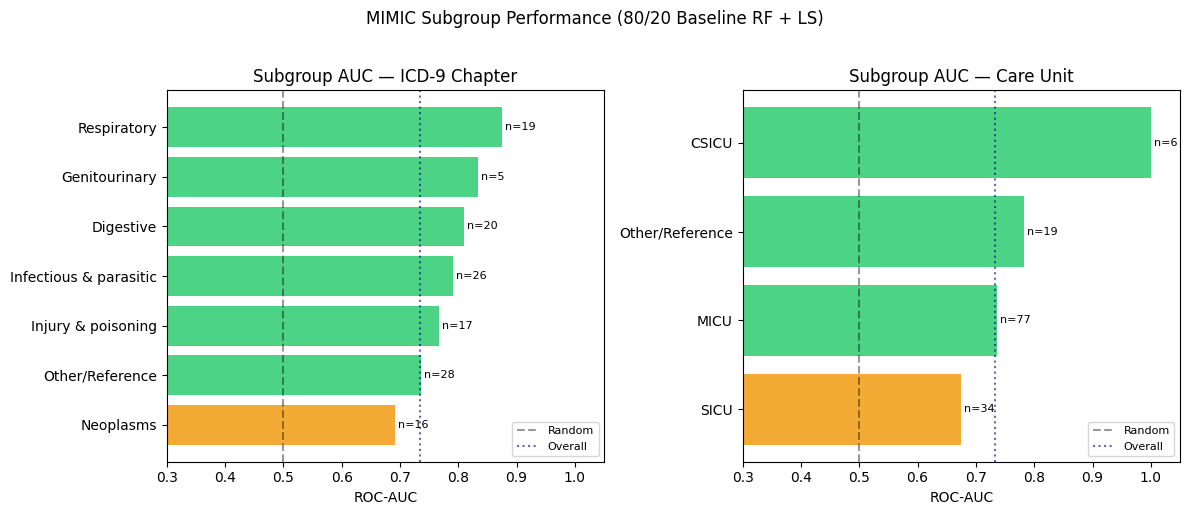

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, sg, title in zip(axes,
    [sg_icd9, sg_care],
    ['ICD-9 Chapter', 'Care Unit']):
    if sg.empty: ax.set_visible(False); continue
    colors = ['#e74c3c' if v < 0.60 else '#f39c12' if v < 0.70 else '#2ecc71'
              for v in sg['auc']]
    bars = ax.barh(sg.index.astype(str), sg['auc'], color=colors, alpha=0.85)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.4, label='Random')
    ax.axvline(roc_auc_score(y_mimic, p_best), color='navy', linestyle=':', alpha=0.6, label='Overall')
    for bar, (idx, row) in zip(bars, sg.iterrows()):
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f"n={int(row['n'])}", va='center', fontsize=8)
    ax.set_xlim(0.3, 1.05)
    ax.set_xlabel('ROC-AUC')
    ax.set_title(f'Subgroup AUC — {title}')
    ax.legend(fontsize=8)

plt.suptitle('MIMIC Subgroup Performance (80/20 Baseline RF + LS)', y=1.02)
plt.tight_layout()
plt.savefig(f'{DOC_DIR}/subgroup_auc_8020.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Decision Curve Analysis (DCA)

Net benefit = (TP/N) − (FP/N) × (threshold / (1 − threshold))

Shows clinical value of each method across a range of risk thresholds. Higher net benefit = better trade-off between true positives and false positives at that threshold.

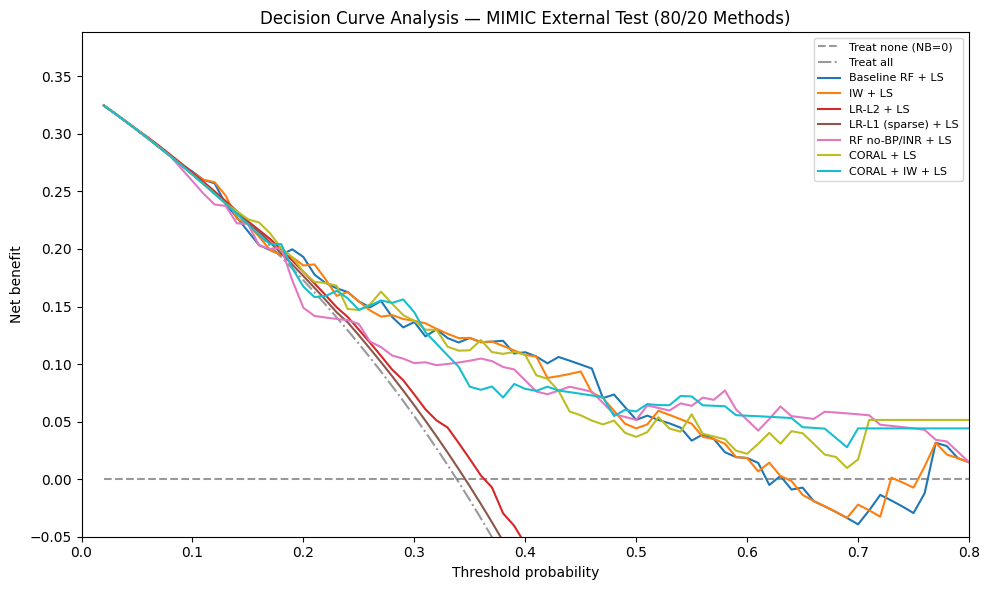

In [ ]:
def dca(y, p, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.02, 0.80, 79)
    n = len(y)
    nb = []
    for thr in thresholds:
        pred = (p >= thr).astype(int)
        tp = ((pred==1)&(y==1)).sum()
        fp = ((pred==1)&(y==0)).sum()
        nb.append(tp/n - fp/n * (thr/(1-thr)))
    return thresholds, np.array(nb)

# treat-all baseline
prev = y_mimic.mean()
thrs_ref = np.linspace(0.02, 0.80, 79)
nb_all   = np.array([prev - (1-prev)*t/(1-t) for t in thrs_ref])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thrs_ref, np.zeros_like(thrs_ref), 'k--', alpha=0.4, label='Treat none (NB=0)')
ax.plot(thrs_ref, nb_all, 'k-.', alpha=0.4, label='Treat all')

colors = plt.cm.tab10(np.linspace(0, 1, len(probs)))
for (name, p), col in zip(probs.items(), colors):
    t, nb = dca(y_mimic.values, p)
    ax.plot(t, nb, label=name, color=col, linewidth=1.5)

ax.set_xlabel('Threshold probability')
ax.set_ylabel('Net benefit')
ax.set_title('Decision Curve Analysis — MIMIC External Test (80/20 Methods)')
ax.set_xlim(0, 0.80)
ax.set_ylim(-0.05, prev + 0.05)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(f'{DOC_DIR}/dca_8020.png', dpi=150)
plt.show()

## 7. Final Summary

In [ ]:
print('='*75)
print('FINAL SUMMARY — All 80/20 Methods on MIMIC (n=136)')
print('='*75)
print(df_all[['AUC','CI_lo','CI_hi','PR','Sens','Spec']].round(3).to_string())
print()

best_auc  = df_all['AUC'].idxmax()
best_sens = df_all['Sens'].idxmax()
print(f'Highest MIMIC AUC  : {best_auc} ({df_all.loc[best_auc,"AUC"]:.3f})')
print(f'Highest MIMIC Sens : {best_sens} ({df_all.loc[best_sens,"Sens"]:.3f})')
print()
print(f'CORAL covariance reduction: {coral_res["frob_reduction_pct"]:.1f}%')
print(f'IW weight std: {iw_weights.std():.4f} (near-zero = weights are uniform = IW had no effect)')
print()
print('── Threshold note ──────────────────────────────────────────────────────')
print('Sens/Spec here use per-method val-tuned thresholds (val Youden → LS-shifted).')
print('This differs from the fixed MIMIC_THR=0.30 used in notebooks 03b and 07,')
print('which was hand-tuned for RF to balance sensitivity and specificity.')
print('AUC and PR-AUC are threshold-independent and are the primary comparison metrics.')
print()
print('── Subgroup note ───────────────────────────────────────────────────────')
print('CSICU subgroup (n=6, AUC=1.000) is too small to be meaningful — disregard.')
print('Age subgroup analysis was removed: age_clean is z-score normalised in the')
print('preprocessed files, making raw-age bins inapplicable.')
print()
print('── Conclusion ──────────────────────────────────────────────────────────')
print('All bootstrap CIs overlap — no method is significantly better than baseline.')
print('CORAL reduced covariance distance by 100% with zero AUC gain, proving the')
print('performance ceiling is not about feature distribution shape.')
print('IW ESS=99.7% confirms importance weighting was a mathematical no-op here.')
print('Best practical choice: label shift correction alone (simplest, best-understood).')

# save final table
df_all.to_csv(f'{DOC_DIR}/final_comparison_8020.csv')
print('\nSaved: documents/final_comparison_8020.csv')


FINAL SUMMARY — All 80/20 Methods on MIMIC (n=136)
                       AUC  CI_lo  CI_hi     PR   Sens   Spec
Method                                                       
Baseline RF + LS     0.734  0.642  0.819  0.642  0.435  0.867
IW + LS              0.734  0.645  0.817  0.642  0.435  0.878
LR-L2 + LS           0.719  0.619  0.811  0.621  0.478  0.844
LR-L1 (sparse) + LS  0.708  0.613  0.799  0.615  0.739  0.478
RF no-BP/INR + LS    0.726  0.632  0.809  0.638  0.457  0.822
CORAL + LS           0.733  0.641  0.815  0.629  0.478  0.844
CORAL + IW + LS      0.715  0.616  0.810  0.635  0.326  0.933

Highest MIMIC AUC  : IW + LS (0.734)
Highest MIMIC Sens : LR-L1 (sparse) + LS (0.739)

CORAL covariance reduction: 100.0%
IW weight std: 0.0573 (near-zero = weights are uniform = IW had no effect)

── Threshold note ──────────────────────────────────────────────────────
Sens/Spec here use per-method val-tuned thresholds (val Youden → LS-shifted).
This differs from the fixed MIMIC_THR=0.3